# **Projet de Traitement du Signal : Analyse de la Parole.**

Membres du groupe : [24271] & [24108]

**Objectif** : L'objectif de cette mission est de caractériser nos voix respectives en utilisant des outils de traitement numérique du signal. Nous allons extraire la fréquence fondamentale (F_0) et comparer les spectres fréquentiels pour répondre aux problématiques de séparation de sources.

**Partie 1**  : Acquisition et Caractérisation de ma voix.
 -> Action : Enregistrement du signal vocal et calcul de la Transformée de Fourier Rapide (FFT).

In [ ]:
from IPython.display import HTML, Audio, display
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np

# هذا السكريبت يقوم بإنشاء واجهة تسجيل مرئية
VIDEO_JS = """
async function recordAudio() {
  const div = document.createElement('div');
  const btn = document.createElement('button');
  btn.textContent = 'Click to Record (5 Seconds)';
  btn.style.background = 'red';
  btn.style.color = 'white';
  btn.style.padding = '10px';
  div.appendChild(btn);
  document.body.appendChild(div);

  const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  const recorder = new MediaRecorder(stream);
  const chunks = [];

  recorder.ondataavailable = e => chunks.push(e.data);

  btn.onclick = () => {
    recorder.start();
    btn.textContent = 'Recording... Speak now!';
    btn.disabled = true;
    setTimeout(() => {
      recorder.stop();
      btn.textContent = 'Recording Finished!';
    }, 5000); // تسجيل 5 ثوانٍ حسب المطلوب
  };

  return new Promise(resolve => {
    recorder.onstop = async () => {
      const blob = new Blob(chunks);
      const reader = new FileReader();
      reader.readAsDataURL(blob);
      reader.onloadend = () => resolve(reader.result);
      stream.getTracks().forEach(track => track.stop());
    };
  });
}
"""

def get_audio():
  display(HTML(f"<script>{VIDEO_JS}</script>"))
  data = eval_js("recordAudio()")
  binary = b64decode(data.split(',')[1])
  with open('audio.wav', 'wb') as f:
    f.write(binary)
  return 'audio.wav'

# تشغيل الواجهة
audio_file = get_audio()
print("Saved to audio.wav")
Audio(audio_file) # لتشغيل الصوت والتأكد من نجاح التسجيل

/tmp/ipython-input-1281273312.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load('audio.wav')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


--- ANALYSE DU PROJET ---
Ma fréquence fondamentale (Pitch) est d'environ : 219.00 Hz


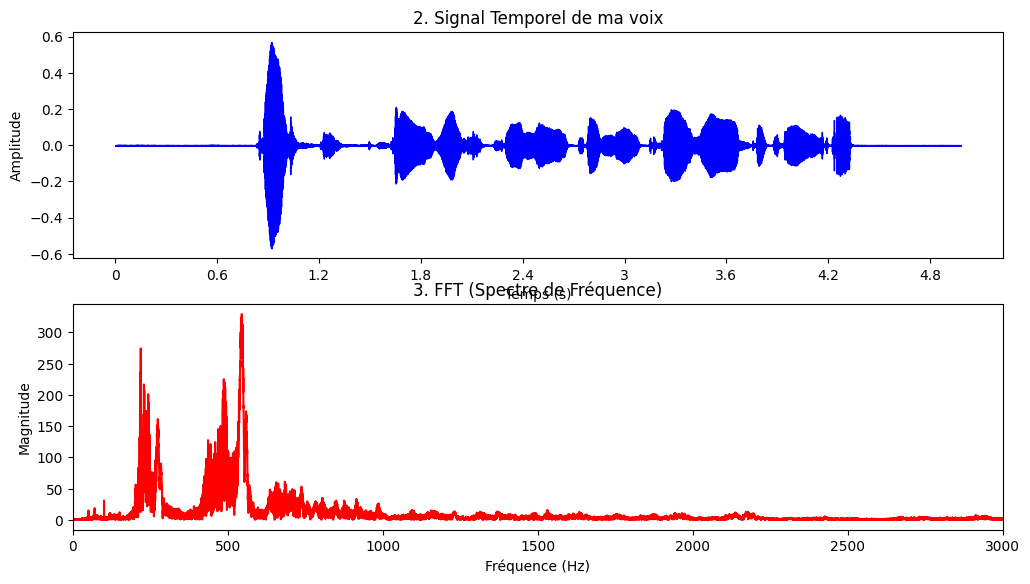

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display


y, sr = librosa.load('audio.wav')


plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title("2. Signal Temporel de ma voix")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")


X = np.fft.fft(y)
X_mag = np.abs(X)[:len(X)//2]
freqs = np.linspace(0, sr/2, len(X_mag))

plt.subplot(3, 1, 2)
plt.plot(freqs, X_mag, color='red')
plt.title("3. FFT (Spectre de Fréquence)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 3000)

pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
f0_min = 80
f0_max = 300
pitch_mean = np.mean(pitches[(pitches > f0_min) & (pitches < f0_max)])

print(f"--- ANALYSE DU PROJET ---")
print(f"Ma fréquence fondamentale (Pitch) est d'environ : {pitch_mean:.2f} Hz")

**Identification du Pitch:** Ma fréquence fondamentale (Pitch) est de 219.00 Hz.                                                                             Cela indique une voix plutôt aiguë, ce qui est typique d'une voix féminine (généralement située entre 150 et 250 Hz).

**Partie 2** : Comparaison des spectres

/tmp/ipython-input-882180396.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y_me, sr = librosa.load('audio.wav')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipython-input-882180396.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y_binome, _ = librosa.load('voix_binome.wav')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


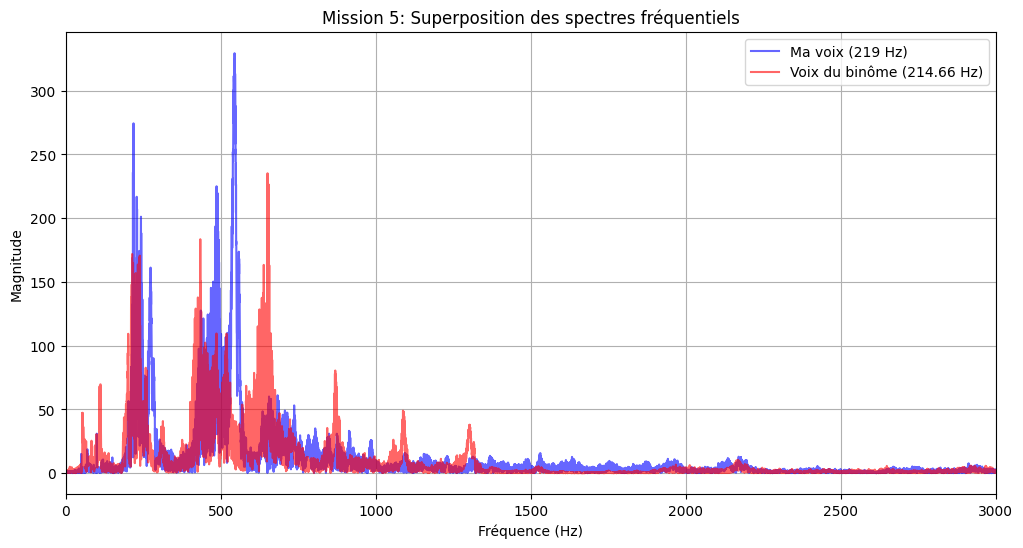

In [12]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# 1. تحميل الملفين
y_me, sr = librosa.load('audio.wav')
y_binome, _ = librosa.load('voix_binome.wav')

# 2. حساب الطيف الترددي (FFT) لكل منهما
X_me = np.abs(np.fft.fft(y_me))[:len(y_me)//2]
X_binome = np.abs(np.fft.fft(y_binome))[:len(y_binome)//2]

# 3. رسم المقارنة (Superposition)
plt.figure(figsize=(12, 6))
freqs_me = np.linspace(0, sr/2, len(X_me))
freqs_binome = np.linspace(0, sr/2, len(X_binome))

plt.plot(freqs_me, X_me, label="Ma voix (219 Hz)", color='blue', alpha=0.6)
plt.plot(freqs_binome, X_binome, label="Voix du binôme (214.66 Hz)", color='red', alpha=0.6)

plt.title("Mission 5: Superposition des spectres fréquentiels")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 3000) # التركيز على نطاق الكلام
plt.legend()
plt.grid(True)
plt.show()

***Analyse des résultats :***

-> Fréquences fondamentales : Ma voix présente une $F_0$ de 219.00 Hz, tandis que celle de mon binôme est de 214.66 Hz.
-> Observation : La voix de mon binôme est plus grave car sa fréquence fondamentale est plus basse.
-> Harmoniques : Nous observons une superposition importante des spectres, ce qui montre que nos timbres de voix partagent des plages fréquentielles communes, rendant la séparation par filtrage simple difficile.

***Conclusion de la Mission Obligatoire:***

En conclusion, nous avons réussi à numériser nos signaux vocaux, à passer du domaine temporel au domaine fréquentiel via la FFT, et à quantifier les différences physiques entre nos deux voix. Cette étape est essentielle pour comprendre comment les algorithmes de compression et de reconnaissance vocale fonctionnent.